In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load thyroid dataset
df = pd.read_csv("thyroid.csv")

# View first rows
df.head()

,0.73,0,1,0.1,0.2,0.3,0.4,0.5,1.1,0.6,0.7,0.8,0.9,0.10,0.11,0.13,0.0006,0.015,0.12,0.082,0.146,3
0,0.24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.030,0.143,0.133,0.108,3
1,0.47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00190,0.024,0.102,0.131,0.078,3
2,0.64,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00090,0.017,0.077,0.090,0.085,3
3,0.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.026,0.139,0.090,0.153,3
4,0.69,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.016,0.086,0.070,0.123,3


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

Dataset Shape: (7199, 22)
<class 'pandas.DataFrame'>
RangeIndex: 7199 entries, 0 to 7198
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.73    7199 non-null   float64
 1   0       7199 non-null   int64  
 2   1       7199 non-null   int64  
 3   0.1     7199 non-null   int64  
 4   0.2     7199 non-null   int64  
 5   0.3     7199 non-null   int64  
 6   0.4     7199 non-null   int64  
 7   0.5     7199 non-null   int64  
 8   1.1     7199 non-null   int64  
 9   0.6     7199 non-null   int64  
 10  0.7     7199 non-null   int64  
 11  0.8     7199 non-null   int64  
 12  0.9     7199 non-null   int64  
 13  0.10    7199 non-null   int64  
 14  0.11    7199 non-null   int64  
 15  0.13    7199 non-null   int64  
 16  0.0006  7199 non-null   float64
 17  0.015   7199 non-null   float64
 18  0.12    7199 non-null   float64
 19  0.082   7199 non-null   float64
 20  0.146   7199 non-null   float64
 21  3       7199 non-null 

0.73      0
0         0
1         0
0.1       0
0.2       0
0.3       0
0.4       0
0.5       0
1.1       0
0.6       0
0.7       0
0.8       0
0.9       0
0.10      0
0.11      0
0.13      0
0.0006    0
0.015     0
0.12      0
0.082     0
0.146     0
3         0
dtype: int64

In [9]:
# Replace missing values with median for numerical columns
df = df.fillna(df.median(numeric_only=True))

# Check again
df.isnull().sum()

0.73      0
0         0
1         0
0.1       0
0.2       0
0.3       0
0.4       0
0.5       0
1.1       0
0.6       0
0.7       0
0.8       0
0.9       0
0.10      0
0.11      0
0.13      0
0.0006    0
0.015     0
0.12      0
0.082     0
0.146     0
3         0
dtype: int64

In [10]:
# Encode categorical columns
label_encoder = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

In [11]:
print(df.columns.tolist())

['0.73', '0', '1', '0.1', '0.2', '0.3', '0.4', '0.5', '1.1', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.13', '0.0006', '0.015', '0.12', '0.082', '0.146', '3']


In [12]:
df.columns = df.columns.str.strip()

In [15]:
df.columns

Index(['0.73', '0', '1', '0.1', '0.2', '0.3', '0.4', '0.5', '1.1', '0.6',
       '0.7', '0.8', '0.9', '0.10', '0.11', '0.13', '0.0006', '0.015', '0.12',
       '0.082', '0.146', '3'],
      dtype='str')

In [20]:
df.head()

,0.73,0,1,0.1,0.2,0.3,0.4,0.5,1.1,0.6,0.7,0.8,0.9,0.10,0.11,0.13,0.0006,0.015,0.12,0.082,0.146,3
0,0.24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.030,0.143,0.133,0.108,3
1,0.47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00190,0.024,0.102,0.131,0.078,3
2,0.64,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00090,0.017,0.077,0.090,0.085,3
3,0.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.026,0.139,0.090,0.153,3
4,0.69,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00025,0.016,0.086,0.070,0.123,3


In [25]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Example dataset (replace with your dataset)
from sklearn.datasets import load_iris
data = load_iris()

# Features and target
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("Shape of X_test:", X_test.shape)
print("Predictions:", y_pred)
print("Accuracy:", accuracy)

Shape of X_test: (30, 4)
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



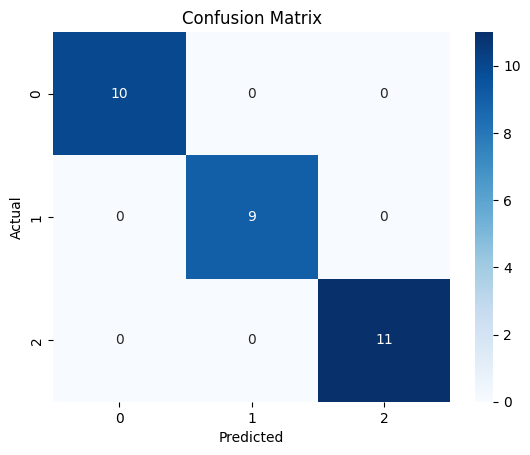

In [26]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


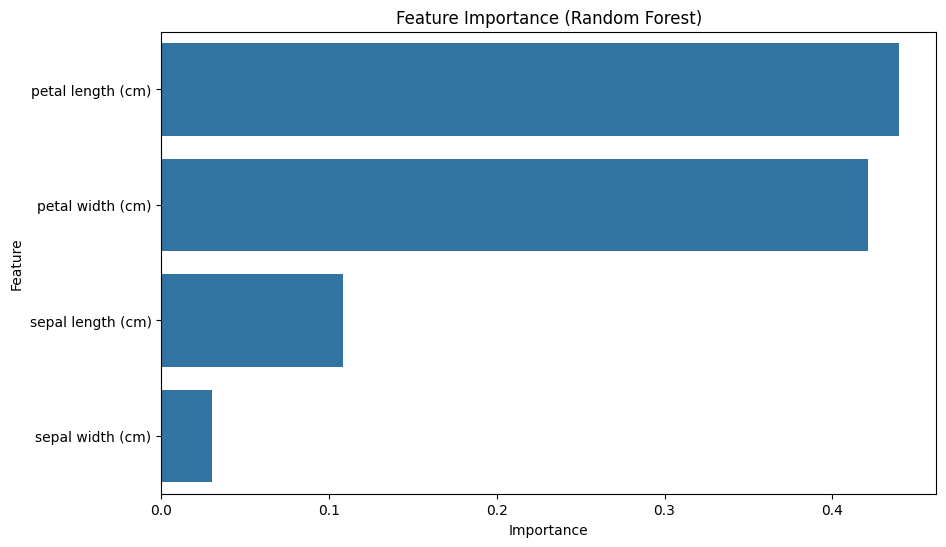

In [27]:
importances = rf_model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance (Random Forest)")
plt.show()